# Dataset exploration

This notebook inspects the Fakeddit multimodal train, validation, test, and comments files. It is read-only and does not modify the raw dataset.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = Path.cwd().parent
RAW_DIR = ROOT / 'data' / 'raw' / 'fakeddit'
sys.path.insert(0, str(ROOT / 'src' / 'data'))

SPLITS = {
    'train': RAW_DIR / 'multimodal_train.tsv',
    'validation': RAW_DIR / 'multimodal_validate.tsv',
    'test': RAW_DIR / 'multimodal_test_public.tsv',
}


In [2]:
def split_summary(path):
    header = pd.read_csv(path, sep='\t', nrows=0)
    rows = sum(len(chunk) for chunk in pd.read_csv(path, sep='\t', dtype=str, chunksize=100_000, keep_default_na=False))
    return {'rows': rows, 'columns': len(header.columns), 'column_names': list(header.columns)}

summaries = pd.DataFrame({name: split_summary(path) for name, path in SPLITS.items()}).T
summaries[['rows', 'columns']]

,rows,columns
train,564000,16
validation,59342,16
test,59319,16


In [3]:
def missingness(path):
    counts = None
    rows = 0
    for chunk in pd.read_csv(path, sep='\t', dtype=str, chunksize=100_000, keep_default_na=False):
        rows += len(chunk)
        current = chunk.apply(lambda col: col.astype(str).str.strip().eq('').sum())
        counts = current if counts is None else counts.add(current, fill_value=0)
    return (counts / rows).sort_values(ascending=False).to_frame('missing_fraction')

missingness(SPLITS['train']).head(10)

,missing_fraction
linked_submission_id,0.702381
domain,0.297619
upvote_ratio,0.297619
num_comments,0.297619
author,0.050904
image_url,0.002720
created_utc,0.000000
clean_title,0.000000
hasImage,0.000000
id,0.000000


In [4]:
frames = {name: pd.read_csv(path, sep='\t', dtype=str, keep_default_na=False) for name, path in SPLITS.items()}
label_columns = ['2_way_label', '3_way_label', '6_way_label']
for label in label_columns:
    display(pd.DataFrame({name: frame[label].value_counts(normalize=True).sort_index() for name, frame in frames.items()}).fillna(0).style.format('{:.2%}'))

,train,validation,test
2_way_label,,,
0,60.62%,60.70%,60.37%
1,39.38%,39.30%,39.63%


,train,validation,test
3_way_label,,,
0,39.38%,39.30%,39.63%
1,2.46%,2.30%,2.52%
2,58.17%,58.40%,57.86%


,train,validation,test
6_way_label,,,
0,39.38%,39.30%,39.63%
1,5.94%,5.93%,5.92%
2,19.01%,19.00%,19.04%
3,2.09%,2.09%,2.06%
4,29.76%,30.01%,29.45%
5,3.83%,3.67%,3.89%


         text_length
count  564000.000000
mean       41.926676
std        31.796946
min         1.000000
25%        19.000000
50%        34.000000
75%        57.000000
max      2785.000000
hasImage values: {'True': 564000}
image URL missing: 1534


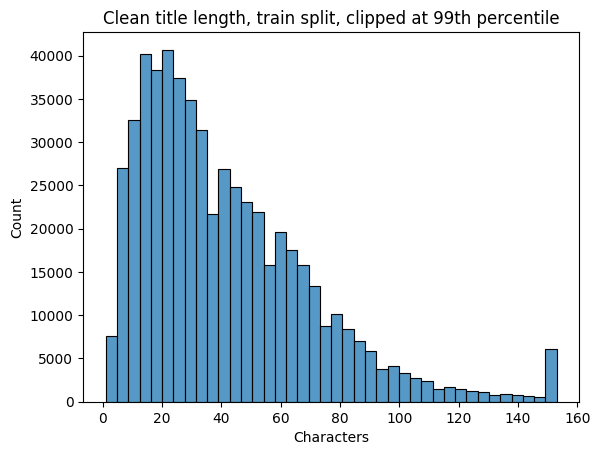

In [5]:
train = frames['train'].copy()
train['text_length'] = train['clean_title'].str.len()
print(train[['text_length']].describe())
print('hasImage values:', train['hasImage'].value_counts().to_dict())
print('image URL missing:', (train['image_url'].str.strip() == '').sum())

sns.histplot(train['text_length'].clip(upper=train['text_length'].quantile(0.99)), bins=40)
plt.title('Clean title length, train split, clipped at 99th percentile')
plt.xlabel('Characters')
plt.show()

In [6]:
comments = pd.read_csv(RAW_DIR / 'all_comments.tsv', sep='\t', usecols=['submission_id'], dtype=str, nrows=100_000, keep_default_na=False)
comments.head()

,submission_id
0,dkdml1
1,dkdml1
2,dkdml1
3,dkdml1
4,dkdml1


## Exploration notes

- Preserve all three label columns until the final classification target is chosen.
- Keep the official train, validation, and test boundaries.
- Treat missing image URLs explicitly because `hasImage` is true for the multimodal files.
- Preserve punctuation and wording in `clean_title`; later BERT preprocessing should handle tokenization.
- Check duplicate titles across splits as a possible leakage consideration.
- Use `id` in the submission tables to join with `submission_id` in the comments file.